# Assignment-4 COMP-5970 Jacob Murrah
## README
Design a small CNN from scratch (5–10 layers), train it on CIFAR-10, then
upgrade it with residual connections and compare. Finally, pretrain one of
your models with a self-supervised objective and fine-tune on labels. You’ll
analyze accuracy, data efficiency, convergence, and learned features.

## Dependencies
- **Python 3.x**
- **numpy**
- **matplotlib**
- **pytorch**
- **torchvision**
- **scikit-learn**
- **seaborn**

*Note: If you are running this notebook in Google Colab, all the required packages are pre-installed.*

## Instructions
1. **Run All Cells:** Please click on \"Runtime\" > \"Run all\" to execute the entire notebook sequentially.
2. **Review the Outputs:** The notebook is organized into several sections. Ensure that all cells run without errors.

## GenAI Usage Declaration
GenAI was used to explain the basics of CNNs, skip connections, residual blocks, and the predictive, contrastive, and mask SSL strategies. I also used GenAI to help me implement the NTXentLoss class that is needed for my SimCLR implementation.

## Statement of Contribution
This was an individual project and I did everything in it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision, torchvision.transforms as transforms
from torch.utils.data import Subset
from collections import defaultdict
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Load CIFAR-10 dataset
CIFAR_CLASSES = [
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, transform=train_transform, download=True
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, transform=test_transform, download=True
)

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=96, num_workers=2, shuffle=True
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=96, shuffle=True
)

100%|██████████| 170M/170M [00:06<00:00, 27.9MB/s]


In [4]:
class EncoderWrapper(nn.Module):
    def __init__(
        self,
        encoder,
        latent_dim=128,
        output_dim=10
    ):
        super().__init__()
        self.encoder = encoder

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

def train_epoch(m, criterion, opt, loader):
    m.train()
    total, correct, loss_sum = 0, 0, 0.0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        opt.zero_grad()

        logits = m(images)
        loss = criterion(logits, labels)

        loss.backward()
        opt.step()

        pred = torch.argmax(logits, dim=1)
        correct += (pred == labels).sum().item()
        loss_sum += loss.item() * labels.size(0)

        total += labels.size(0)

    return loss_sum / total, correct / total

def test_epoch(m, criterion):
    m.eval()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = m(images)
            loss = criterion(logits, labels)

            pred = torch.argmax(logits, dim=1)
            correct += (pred == labels).sum().item()
            loss_sum += loss.item() * labels.size(0)

            total += labels.size(0)

    return loss_sum / total, correct / total

def train_model(m, c, o, l):
    history = defaultdict(list)
    for epoch in range(30):
        tr_loss, tr_acc = train_epoch(m, c, o, l)
        te_loss, te_acc = test_epoch(m, c)

        print(
            "ep%d: tr_loss: %.3f, tr_acc: %.3f | te_loss: %.3f, te_acc: %.3f" % (
                epoch, tr_loss, tr_acc, te_loss, te_acc
            )
        )

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

    return history

# Task 1) Small CNN (from scratch)
Implement and train a compact CNN classifier on CIFAR-10 with the
following specifications:
- 5–10 learnable layers (conv/normalization/activation/linear count
toward depth; pooling doesn’t).
- ≤ 1.5M parameters (show a param count).
- Use standard training (cross-entropy) and reasonable augments
(random crop/flip, optional color jitter).
- Train to reasonable test accuracy (don’t overtrain; ~20–30 epochs or
early stopping is fine).

## Description of Approach
For my CNN I wanted to add as many convolution layers (deeper network) and as many parameters as possible to my encoder because at our scale this generally leads to better accuracy. Given our constraints of 5-10 learnable layers the clear choice for the number of convolutions is 3 since for each convolution I will also need to apply normalization and an activation function. With my 3 convolutions, 3 normalizations, and 3 activations I am left with a single learnable layer to be used in flattening the features to reach our limit of 10 learnable layers. Once my architecture was defined I choose dimensions that scaled progressively in order to represent a deeper set of features without exceeding the parameter limit. I wrap my encoder to take my latent features and create my 10 final class predictions for each of the respective CIFAR10 classes. In order to reduce overfitting I added color jitter, random horizontal flips, and random cropping to my images as well as adding dropout (0.5 is standard) before the fully connected linear layer.

In [5]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=64,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv3 = nn.Conv2d(
            in_channels=128,
            out_channels=256,
            kernel_size=3,
            padding=1,
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [6]:
model1 = EncoderWrapper(encoder=SimpleCNNEncoder()).to(device)
opt1 = torch.optim.SGD(
    model1.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion1 = nn.CrossEntropyLoss()

print("--- Training SimpleCNNEncoder Model ---")
history1 = train_model(model1, criterion1, opt1, train_loader)

--- Training SimpleCNNEncoder Model ---
ep0: tr_loss: 1.829, tr_acc: 0.328 | te_loss: 1.444, te_acc: 0.466
ep1: tr_loss: 1.490, tr_acc: 0.458 | te_loss: 1.229, te_acc: 0.555
ep2: tr_loss: 1.339, tr_acc: 0.517 | te_loss: 1.095, te_acc: 0.610
ep3: tr_loss: 1.232, tr_acc: 0.561 | te_loss: 0.998, te_acc: 0.650
ep4: tr_loss: 1.169, tr_acc: 0.581 | te_loss: 1.002, te_acc: 0.646
ep5: tr_loss: 1.116, tr_acc: 0.603 | te_loss: 0.932, te_acc: 0.674
ep6: tr_loss: 1.073, tr_acc: 0.620 | te_loss: 0.910, te_acc: 0.672
ep7: tr_loss: 1.039, tr_acc: 0.633 | te_loss: 0.884, te_acc: 0.690
ep8: tr_loss: 1.008, tr_acc: 0.644 | te_loss: 0.837, te_acc: 0.705
ep9: tr_loss: 0.982, tr_acc: 0.654 | te_loss: 0.843, te_acc: 0.710
ep10: tr_loss: 0.961, tr_acc: 0.660 | te_loss: 0.817, te_acc: 0.710
ep11: tr_loss: 0.946, tr_acc: 0.666 | te_loss: 0.763, te_acc: 0.735
ep12: tr_loss: 0.923, tr_acc: 0.674 | te_loss: 0.781, te_acc: 0.726
ep13: tr_loss: 0.907, tr_acc: 0.680 | te_loss: 0.727, te_acc: 0.744
ep14: tr_loss: 0.8

**Task 1 Part a)** Model diagram
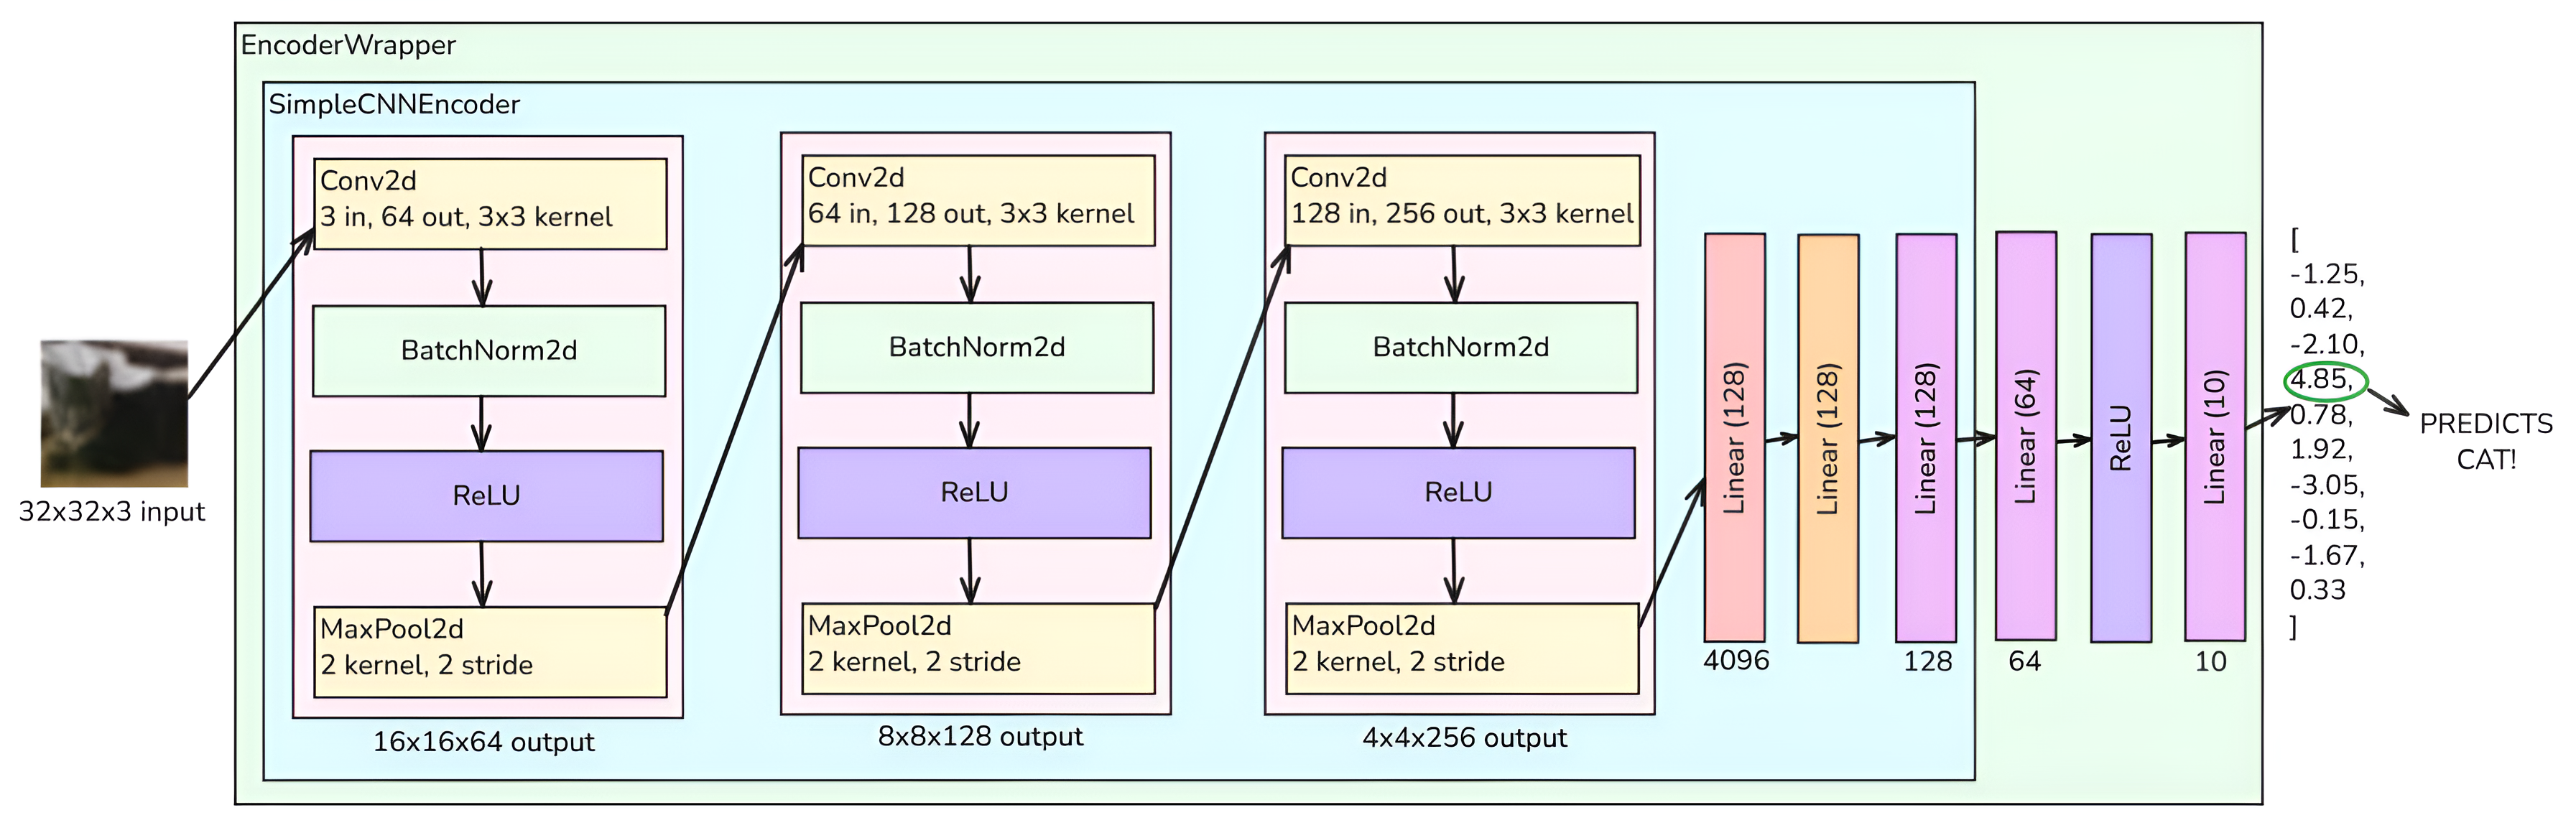

My SimpleCNNEncoder extracts the features of the input 32x32x3 RGB image and outputs a 128 latent vector. The EncoderWrapper class acts as the classifier head and takes the 128 dimension latent vector and outputs the 10 output logits that represent the CIFAR10 classes.

Total Parameters: 904586


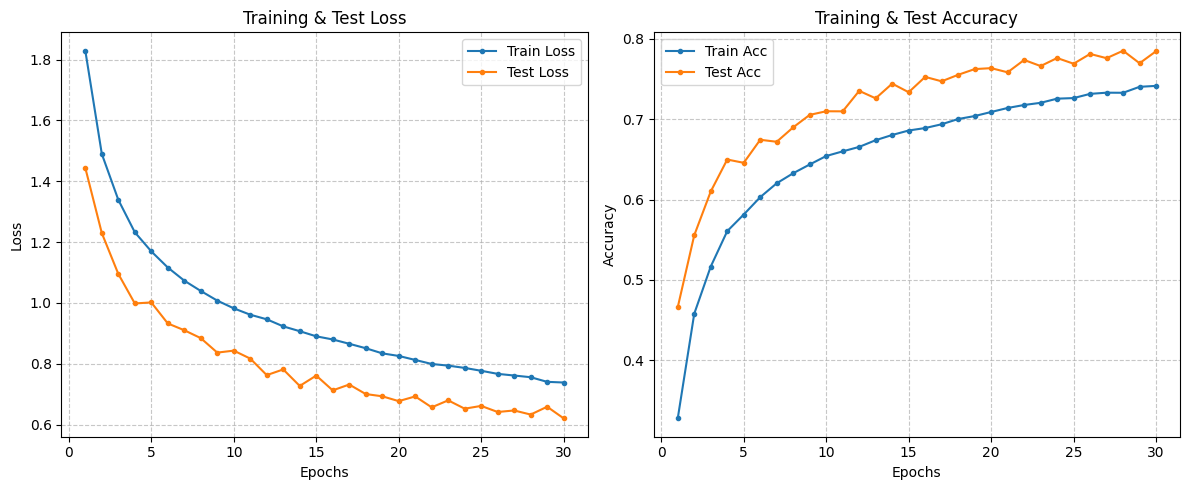

In [7]:
# param count
param_count = sum(p.numel() for p in model1.parameters())
print(f"Total Parameters: {param_count}")

# plot training curves
epochs = range(1, len(history1['train_loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history1['test_loss'], label='Test Loss', marker='.')
plt.title('Training & Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, history1['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history1['test_acc'], label='Test Acc', marker='.')
plt.title('Training & Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Final Accuracy:  0.7847


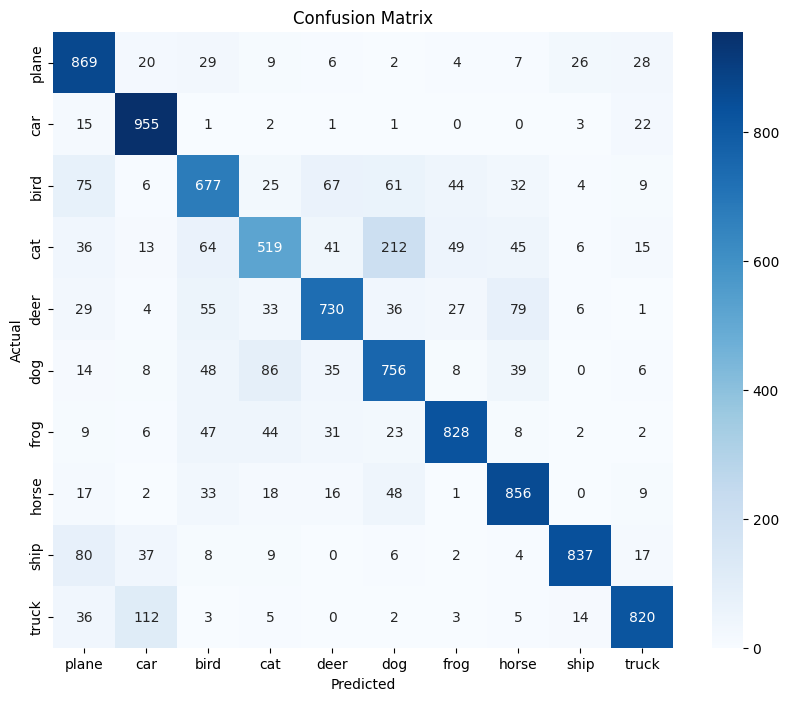

In [8]:
# final test accuracy & confusion matrix
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model1(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

final_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print("Final Accuracy: ", final_acc)

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CIFAR_CLASSES,
    yticklabels=CIFAR_CLASSES
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Task 2) Improve your CNN
Modify your CNN to include identity (skip) connections where shapes
match (e.g., two convs per block), and projection when they don’t (1×1 conv).
Make sure to follow the below specifications:
- Keep overall depth and parameter budget comparable (±20% is fine).
- Reuse the same optimizer/augments unless you justify changes.
- Train and compare against Part A.

## Description of Approach
When using skip connections the original input into a residual block can bypass (skip) layers in order to preserve the input and pass it deeper into the network. Skip connections are primarily useful in deeper networks since deeper networks tend to lose the original representation of the input. Since our network is super shallow, I create a residual block archtiecture that can make the most use of skip connections. I choose to design each residual block to only have a single convolution and normalization. In this architecture the original input will be added to the normalization function's output and then passed into an activation after only a single convolution. This design enables my architecture to be comparable to task 1 if I implement 3 residual blocks in my network. I use projection to change the size of the input if the original size does not match the output of the normalization.

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)

        if in_channels != out_channels:
            self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            self.proj_bn = nn.BatchNorm2d(out_channels)
        else:
            self.proj = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x

        out = self.conv(x)
        out = self.bn(out)

        if self.proj is not None:
            identity = self.proj(identity)
            identity = self.proj_bn(identity)

        out += identity
        out = self.relu(out)

        return out


class SkipCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, latent_ch=128):
        super().__init__()
        self.dropout = nn.Dropout(0.5)

        self.block1 = ResidualBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block2 = ResidualBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.block3 = ResidualBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc = nn.Linear(
            in_features=256 * 4 * 4, out_features=latent_ch
        )

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))

        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

In [10]:
model2 = EncoderWrapper(encoder=SkipCNNEncoder()).to(device)
opt2 = torch.optim.SGD(
    model2.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion2 = nn.CrossEntropyLoss()

print("--- Training SkipCNNEncoder Model ---")
history2 = train_model(model2, criterion2, opt2, train_loader)

--- Training SkipCNNEncoder Model ---
ep0: tr_loss: 1.804, tr_acc: 0.336 | te_loss: 1.400, te_acc: 0.492
ep1: tr_loss: 1.486, tr_acc: 0.458 | te_loss: 1.243, te_acc: 0.556
ep2: tr_loss: 1.349, tr_acc: 0.511 | te_loss: 1.102, te_acc: 0.607
ep3: tr_loss: 1.256, tr_acc: 0.549 | te_loss: 1.038, te_acc: 0.627
ep4: tr_loss: 1.190, tr_acc: 0.572 | te_loss: 0.962, te_acc: 0.658
ep5: tr_loss: 1.145, tr_acc: 0.593 | te_loss: 0.948, te_acc: 0.667
ep6: tr_loss: 1.102, tr_acc: 0.606 | te_loss: 0.876, te_acc: 0.694
ep7: tr_loss: 1.067, tr_acc: 0.620 | te_loss: 0.902, te_acc: 0.684
ep8: tr_loss: 1.034, tr_acc: 0.634 | te_loss: 0.856, te_acc: 0.698
ep9: tr_loss: 1.013, tr_acc: 0.643 | te_loss: 0.837, te_acc: 0.710
ep10: tr_loss: 0.989, tr_acc: 0.648 | te_loss: 0.810, te_acc: 0.719
ep11: tr_loss: 0.964, tr_acc: 0.661 | te_loss: 0.821, te_acc: 0.712
ep12: tr_loss: 0.947, tr_acc: 0.665 | te_loss: 0.787, te_acc: 0.721
ep13: tr_loss: 0.925, tr_acc: 0.675 | te_loss: 0.799, te_acc: 0.718
ep14: tr_loss: 0.908

**Task 2 Part a)** Residual Block Design

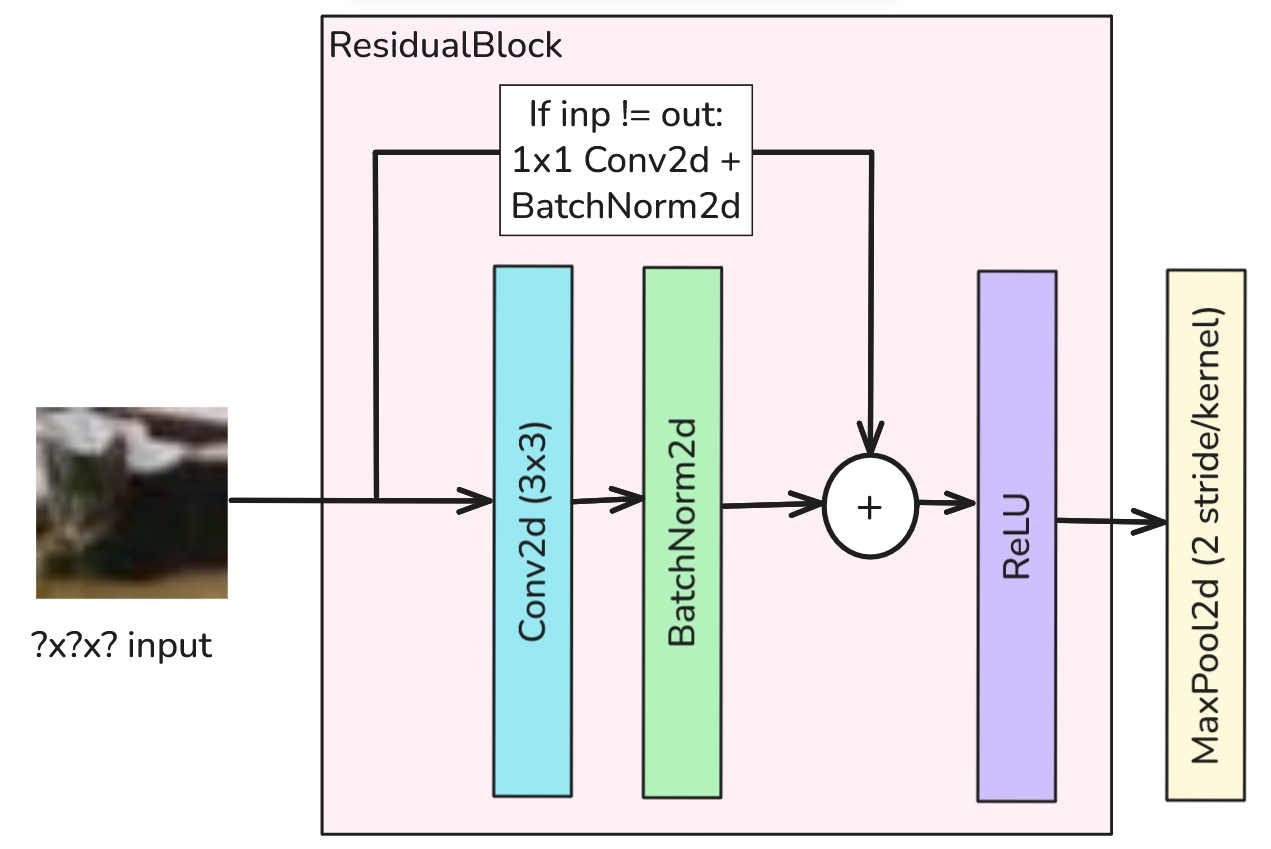

The primary path of my residual block has a single convolution followed by a normalization layer. My skip connection (the other path) will be added to the output of that normalization layer and then everything is passed through a ReLU activation function. If the size of my input does not match the output of the normalization layer, I perform a projection.

Skip CNN Final Test Accuracy: 78.72%


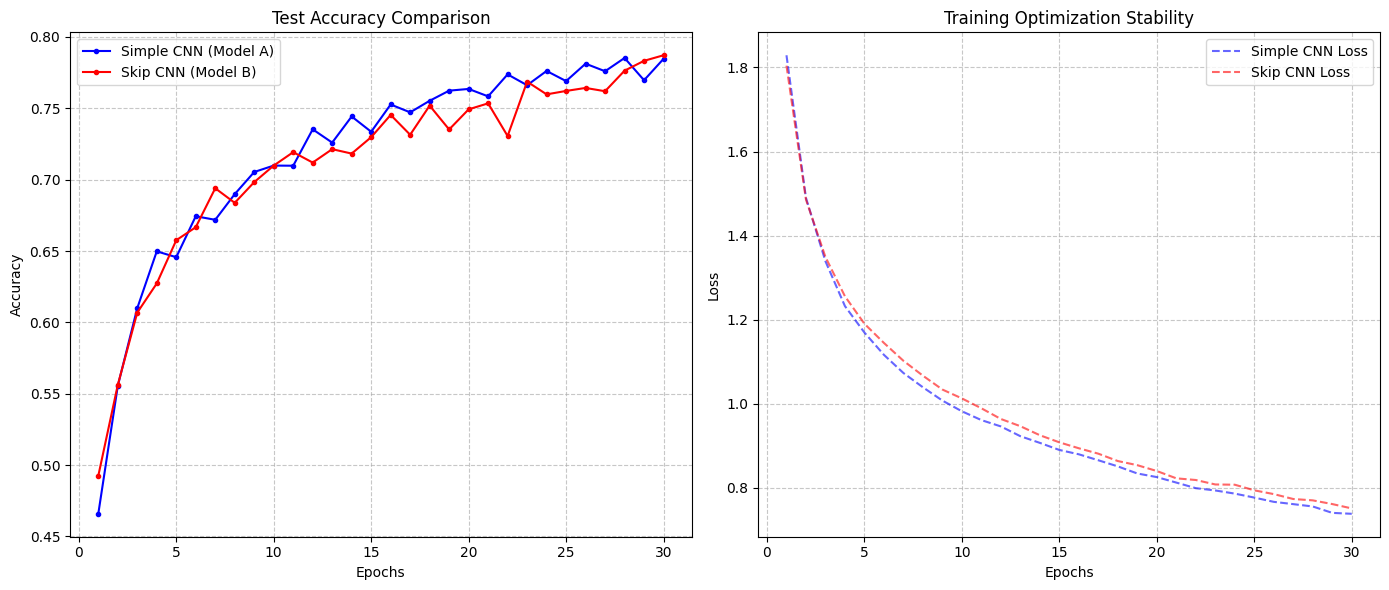

In [11]:
# Task 2 Part b) Training curves overlay (A vs. B), final test accuracy
model2.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc_skip = 100 * correct / total
print(f'Skip CNN Final Test Accuracy: {final_acc_skip:.2f}%')

epochs = range(1, len(history2['train_loss']) + 1)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, history1['test_acc'], 'b-', label='Simple CNN (Model A)', marker='.')
plt.plot(epochs, history2['test_acc'], 'r-', label='Skip CNN (Model B)', marker='.')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history1['train_loss'], 'b--', label='Simple CNN Loss', alpha=0.6)
plt.plot(epochs, history2['train_loss'], 'r--', label='Skip CNN Loss', alpha=0.6)
plt.title('Training Optimization Stability')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

**Task 2 Part c)** Brief Analysis

NOTE: All numbers are taken from the 30th epoch during training of each respective model.
- Optimization Stability (loss smoothness): For both networks the training loss smoothly decreases and the training accuracy begins to stabalize out around 73.5%. The testing is less smooth but still decreases consistently for both models. Both models had slightly high testing accuracy which stablized at around 77.5%. For the loss smoothness there is minimal difference between the two models.
- Convergence Speed (# epochs to 90% of final testing accuracy):
    *   SimpleCNNEncoder: 0.9 * 0.785 = 0.7065 --> Epoch 9 (te_acc=0.710)
    *   SkipCNNEncoder: 0.9 * 0.785 = 0.7083 --> Epoch 9 (te_acc=0.710)
  
    Both models have the same convergence speed!
- Generalization Differences (between train acc and test acc):
    *   SimpleCNNEncoder: |0.742 - 0.785| = 0.043 gap
    *   SkipCNNEncoder: |0.738 - 0.787| = 0.049 gap

    While the SkipCNN has a larger overall final accuracy the gap between the test and train accuracy is larger. The differences are minimal.
  
Overall, there was minimal difference between the simple and skip CNN models. Intuitively this makes sense because skip connections provide benefit to deep networks (~10+ convolutions) and don't really effect shallow networks. Due to the simplicity of the SimpleCNNEncoder, I would choose the simple model given the task constraints.

# Task 3) Self-Supervised Pretraining + Fine-tuning
Pretrain either your vanilla CNN or residual CNN without labels, then
fine-tune on labeled CIFAR-10, with the following specifications:
- Choose one SSL strategy from the below list:
  * Predictive: Rotation prediction (0/90/180/270) or patch jigsaw.
  * Contrastive: SimCLR-style instance discrimination (two strong
views).
  * Masked modeling / reconstruction: Mask random patches and
predict pixels/features.
- Follow the below training protocol:
  * Pretrain on the entire unlabeled CIFAR-10 train set (labels
hidden).
  * Evaluation B (Fine-tune): Unfreeze and fine-tune end-to-end
with 10% labeled data (make sure to sample uniformly across
classes!).

## Description of Approach
I chose the SimCLR-style instance discrimination because it provides good performance and I was also interested in learning how to implement it. In general, the longer we train on our pretraining task the better the model will perform. SimCLR takes a very long time for each pretrain epoch so I only pretrain for 15 epochs. Note that for SimCLR we use the NT-Xent loss function to find the 'similarity' between image views. After pretraining is done I perform a warmup of 5 epochs on the head of my new model in order to stabalize my future training. After pretraining, my model head is randomly initialized and this warmup helps the head better represent the image features. Finally, I perform my fine-tuning by training the model on the balanced 10% of the dataset. In order to verify if my approach worked I compare my results to a model trained on 10% of the data with no pretraining or fine-tuning.

In [12]:
class SimCLRTransform:
    def __init__(self, transform):
        self.transform = transform

    def __call__(self, x):
        return self.transform(x), self.transform(x)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]

        features = torch.cat([z_i, z_j], dim=0)

        features = F.normalize(features, dim=1)
        similarity_matrix = torch.matmul(features, features.T)

        labels = torch.cat([
            torch.arange(batch_size) + batch_size,
            torch.arange(batch_size)
        ], dim=0).to(features.device)

        mask = torch.eye(labels.shape[0], dtype=torch.bool).to(features.device)
        similarity_matrix.masked_fill_(mask, -9e15)

        logits = similarity_matrix / self.temperature
        loss = F.cross_entropy(logits, labels)
        return loss

def get_balanced_10_percent_subset(dataset, num_classes=10):
    indices = []
    targets = np.array(dataset.targets)
    for c in range(num_classes):
        class_indices = np.where(targets == c)[0]
        n_samples = int(len(class_indices) * 0.10)
        selected = np.random.choice(class_indices, n_samples, replace=False)
        indices.extend(selected)

    return Subset(dataset, indices)

In [13]:
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010]
    )
])
simclr_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    transform=SimCLRTransform(simclr_transform),
    download=True
)
simclr_loader = torch.utils.data.DataLoader(
    simclr_dataset,
    batch_size=96,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

model_simclr = EncoderWrapper(
    encoder=SimpleCNNEncoder(), output_dim=64
).to(device)
opt_simclr = torch.optim.SGD(
    model_simclr.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion_simclr = NTXentLoss(temperature=0.5)

sub10_dataset = get_balanced_10_percent_subset(train_dataset)
sub10_loader = torch.utils.data.DataLoader(
    sub10_dataset, batch_size=96, shuffle=True, num_workers=2
)

In [14]:
print("--- SimCLR Pretraining ---")
for epoch in range(15):
    model_simclr.train()
    total_loss = 0
    for (img1, img2), _ in simclr_loader:
        img1 = img1.to(device)
        img2 = img2.to(device)

        opt_simclr.zero_grad()

        z1 = model_simclr(img1)
        z2 = model_simclr(img2)

        loss = criterion_simclr(z1, z2)

        loss.backward()
        opt_simclr.step()

        total_loss += loss.item()

    print(f"SimCLR Epoch {epoch+1}: Loss {total_loss / len(simclr_loader):.4f}")

model3 = EncoderWrapper(encoder=model_simclr.encoder, output_dim=10).to(device)
criterion3 = nn.CrossEntropyLoss()

for param in model3.encoder.parameters():
    param.requires_grad = False

print("\n--- Step A: Linear Probing (Head Only) ---")
opt3_head = torch.optim.SGD(model3.head.parameters(), lr=0.001, momentum=0.9)
for epoch in range(5):
    model3.train()
    for images, labels in sub10_loader:
        images = images.to(device)
        labels= labels.to(device)

        opt3_head.zero_grad()
        logits = model3(images)

        loss = criterion3(logits, labels)
        loss.backward()

        opt3_head.step()

    print(f"Warmup Epoch {epoch+1} Done")

print("\n--- Evaluation B: Fine-Tuning (Unfrozen) ---")
for param in model3.encoder.parameters():
    param.requires_grad = True

opt3_full = torch.optim.SGD(model3.parameters(), lr=0.001, momentum=0.9)
history3 = train_model(model3, criterion3, opt3_full, sub10_loader)

--- SimCLR Pretraining ---
SimCLR Epoch 1: Loss 4.5180
SimCLR Epoch 2: Loss 4.3261
SimCLR Epoch 3: Loss 4.2580
SimCLR Epoch 4: Loss 4.2121
SimCLR Epoch 5: Loss 4.1792
SimCLR Epoch 6: Loss 4.1618
SimCLR Epoch 7: Loss 4.1458
SimCLR Epoch 8: Loss 4.1347
SimCLR Epoch 9: Loss 4.1266
SimCLR Epoch 10: Loss 4.1130
SimCLR Epoch 11: Loss 4.1022
SimCLR Epoch 12: Loss 4.0931
SimCLR Epoch 13: Loss 4.0898
SimCLR Epoch 14: Loss 4.0823
SimCLR Epoch 15: Loss 4.0786

--- Step A: Linear Probing (Head Only) ---
Warmup Epoch 1 Done
Warmup Epoch 2 Done
Warmup Epoch 3 Done
Warmup Epoch 4 Done
Warmup Epoch 5 Done

--- Evaluation B: Fine-Tuning (Unfrozen) ---
ep0: tr_loss: 1.744, tr_acc: 0.368 | te_loss: 1.588, te_acc: 0.400
ep1: tr_loss: 1.633, tr_acc: 0.410 | te_loss: 1.522, te_acc: 0.422
ep2: tr_loss: 1.559, tr_acc: 0.427 | te_loss: 1.445, te_acc: 0.467
ep3: tr_loss: 1.539, tr_acc: 0.433 | te_loss: 1.422, te_acc: 0.469
ep4: tr_loss: 1.481, tr_acc: 0.459 | te_loss: 1.353, te_acc: 0.500
ep5: tr_loss: 1.468, t

In [16]:
# accuracy without the SSL task on 10% of the data
model4 = EncoderWrapper(encoder=SimpleCNNEncoder()).to(device)
opt4 = torch.optim.SGD(
    model4.parameters(), lr=0.001, weight_decay=1e-4, momentum=0.9
)
criterion4 = nn.CrossEntropyLoss()
history_4 = train_model(model4, criterion4, opt4, sub10_loader)

ep0: tr_loss: 2.258, tr_acc: 0.153 | te_loss: 2.143, te_acc: 0.229
ep1: tr_loss: 2.075, tr_acc: 0.241 | te_loss: 1.920, te_acc: 0.344
ep2: tr_loss: 1.933, tr_acc: 0.298 | te_loss: 1.814, te_acc: 0.352
ep3: tr_loss: 1.870, tr_acc: 0.313 | te_loss: 1.728, te_acc: 0.383
ep4: tr_loss: 1.805, tr_acc: 0.336 | te_loss: 1.652, te_acc: 0.400
ep5: tr_loss: 1.745, tr_acc: 0.356 | te_loss: 1.600, te_acc: 0.415
ep6: tr_loss: 1.712, tr_acc: 0.368 | te_loss: 1.554, te_acc: 0.443
ep7: tr_loss: 1.672, tr_acc: 0.384 | te_loss: 1.504, te_acc: 0.464
ep8: tr_loss: 1.635, tr_acc: 0.401 | te_loss: 1.485, te_acc: 0.457
ep9: tr_loss: 1.597, tr_acc: 0.417 | te_loss: 1.481, te_acc: 0.458
ep10: tr_loss: 1.565, tr_acc: 0.424 | te_loss: 1.432, te_acc: 0.483
ep11: tr_loss: 1.551, tr_acc: 0.438 | te_loss: 1.421, te_acc: 0.469
ep12: tr_loss: 1.525, tr_acc: 0.442 | te_loss: 1.436, te_acc: 0.486
ep13: tr_loss: 1.491, tr_acc: 0.448 | te_loss: 1.346, te_acc: 0.517
ep14: tr_loss: 1.487, tr_acc: 0.466 | te_loss: 1.370, te_a

**Task 3 Part a)** SSL Objective Description + Discussion
- SSL Objective and Augmentations: I chose to use the contrastive SimCLR-style instance discrimination SSL strategy. The core idea is that the model should maximize the similarity score for views from the same image and minimize the score for views that are from different images. These comparisons are done between all views within a batch. I used RandomResizedCrop, RandomHorizontalFlip, ColorJitter, and RandomGrayscale as augmentations to help my model learn the true invariant features of the classes instead of less relevant cues.
- Discussion of Benefit: The self-supervised pre-training and fine-tuning clearly improved my accuracy. Without the SimCLR pre-training and fine tuning my model obtained a final accuracy of 59.3%. With the SimCLR pre-training and fine-tuning I obtained an accuracy of 62.1%. Note that for my SimCLR pretraining I only performed 15 epochs. If i pretrained for longer (~50-100 epochs) my accuracy would have only increased as the SimCLR loss decreased.